**Cloud Setup, Data Ingestion, and Exploration**

In [ ]:
# Installing and importing packages
!pip install google-cloud-storage -q

import pandas as pd
import sqlite3
import requests
from google.colab import auth
from google.cloud import storage

In [ ]:
# Authenticateing with our Google account
auth.authenticate_user()

bucket_name = "ds2002-capstone-sp26-v2"
client = storage.Client()
bucket = client.bucket(bucket_name)

for blob in bucket.list_blobs(prefix="raw-data/"):
    print(blob.name)

raw-data/charging_sessions.csv
raw-data/energy_and_demand.db
raw-data/grid_operators.csv
raw-data/station_locations.csv
raw-data/vehicle_types.csv


In [ ]:
# Creating our team folder
team_folder = "team-13/"

blob = bucket.blob(team_folder + "README.txt")
blob.upload_from_string("Team folder created for DS2002 capstone.")
print("Team folder created.")

Team folder created.


In [ ]:
# Downloading raw data programmatically
raw_files = [
    "charging_sessions.csv",
    "station_locations.csv",
    "vehicle_types.csv",
    "grid_operators.csv",
    "energy_and_demand.db"
]

for file in raw_files:
    source = f"raw-data/{file}"
    destination = f"/content/{file}"
    bucket.blob(source).download_to_filename(destination)
    print(f"Downloaded {file}")

Downloaded charging_sessions.csv
Downloaded station_locations.csv
Downloaded vehicle_types.csv
Downloaded grid_operators.csv
Downloaded energy_and_demand.db


In [ ]:
# Loading CSV files
sessions = pd.read_csv("/content/charging_sessions.csv")
stations = pd.read_csv("/content/station_locations.csv")
vehicles = pd.read_csv("/content/vehicle_types.csv")
grid = pd.read_csv("/content/grid_operators.csv")

dataframes = {
    "charging_sessions": sessions,
    "station_locations": stations,
    "vehicle_types": vehicles,
    "grid_operators": grid
}

In [ ]:
# Looking at each dataset
for name, df in dataframes.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Shape:")
    print(df.shape)

    print("\nDtypes:")
    print(df.dtypes)

    print("\nInfo:")
    df.info()

    print("\nDescribe:")
    display(df.describe(include="all"))

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

    display(df.head())


charging_sessions
Shape:
(27451, 11)

Dtypes:
session_id         object
station_id         object
vehicle_id         object
session_start      object
session_end        object
kwh_delivered     float64
session_type       object
cost_usd           object
payment_method     object
connector_used     object
user_id            object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27451 entries, 0 to 27450
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   session_id      27451 non-null  object 
 1   station_id      27451 non-null  object 
 2   vehicle_id      27374 non-null  object 
 3   session_start   27451 non-null  object 
 4   session_end     27451 non-null  object 
 5   kwh_delivered   27361 non-null  float64
 6   session_type    27451 non-null  object 
 7   cost_usd        27384 non-null  object 
 8   payment_method  27451 non-null  object 
 9   connector_used  27385 non-null  objec

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
count,27451,27451,27374,27451,27451,27361.000000,27451,27384,27451,27385,27451
unique,26951,36,42,26862,26871,NaN,3,4814,9,4,8552
top,SES-003140,STN-010,VH-014,05/23/2025 03:15,09/22/2025 15:49,NaN,DC Fast Charge,2.94,debit_card,J1772,U-1307
freq,2,1543,1645,3,3,NaN,13656,36,3110,6986,12
mean,NaN,NaN,NaN,NaN,NaN,30.843686,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22.797530,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,-79.090000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,14.080000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.920000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,44.920000,NaN,NaN,NaN,NaN,NaN



Missing values:
session_id         0
station_id         0
vehicle_id        77
session_start      0
session_end        0
kwh_delivered     90
session_type       0
cost_usd          67
payment_method     0
connector_used    66
user_id            0
dtype: int64

Duplicates:
486


,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
0,SES-005321,STN-013,VH-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,Level 1,0.53,credit card,J1772,U-4469
1,SES-021125,STN-012,VH-005,10-19-2025 17:10:08,10-19-2025 18:40:08,13.69,DC Fast Charge,1.92,debit_card,CHAdeMO,U-4434
2,SES-026798,STN-007,VEH#0005,12/30/2025 07:30,12/30/2025 08:21,9.62,Level 1,3.56,Credit Card,CCS,U-6845
3,SES-008299,STN-006,VH-005,04-28-2025 02:35:41,04-28-2025 04:52:41,70.99,DC Fast Charge,26.27,app_wallet,Tesla Supercharger,U-7854
4,SES-018503,STN-012,VH-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,Level 2,2.84,credit card,CCS,U-2903



station_locations
Shape:
(21, 8)

Dtypes:
station_id       object
station_name     object
city             object
state            object
zip_code          int64
latitude        float64
longitude       float64
region           object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    21 non-null     object 
 1   station_name  21 non-null     object 
 2   city          21 non-null     object 
 3   state         21 non-null     object 
 4   zip_code      21 non-null     int64  
 5   latitude      20 non-null     float64
 6   longitude     20 non-null     float64
 7   region        20 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.4+ KB

Describe:


...

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer
0,VH-001,Tesla Model 3,Sedan,CCS,75.0,Tesla
1,VEH#0001,TESLA MODEL 3,SEDAN,CCS,NaN,TESLA
2,V_tesla_model_3,tesla model 3,sedan,ccs,75.0,tesla
3,VH-002,Tesla Model Y,SUV,CCS,NaN,Tesla
4,VEH#0002,TESLA MODEL Y,SUV,CCS,NaN,TESLA



grid_operators
Shape:
(5, 7)

Dtypes:
operator_id               object
operator_name             object
city                      object
state                     object
avg_daily_capacity_mw      int64
peak_capacity_mw          object
cost_per_kwh             float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   operator_id            5 non-null      object 
 1   operator_name          5 non-null      object 
 2   city                   5 non-null      object 
 3   state                  5 non-null      object 
 4   avg_daily_capacity_mw  5 non-null      int64  
 5   peak_capacity_mw       5 non-null      object 
 6   cost_per_kwh           4 non-null      float64
dtypes: float64(1), int64(1), object(5)
memory usage: 412.0+ bytes

Describe:


,operator_id,operator_name,city,state,avg_daily_capacity_mw,peak_capacity_mw,cost_per_kwh
count,5,5,5,5,5.000000,5,4.00000
unique,5,5,5,1,NaN,5,NaN
top,GO-CVL,Charlottesville Energy Cooperative,Charlottesville,VA,NaN,240,NaN
freq,1,1,1,5,NaN,1,NaN
mean,NaN,NaN,NaN,NaN,290.000000,NaN,0.12500
std,NaN,NaN,NaN,NaN,133.041347,NaN,0.01291
min,NaN,NaN,NaN,NaN,120.000000,NaN,0.11000
25%,NaN,NaN,NaN,NaN,200.000000,NaN,0.11750
50%,NaN,NaN,NaN,NaN,300.000000,NaN,0.12500
75%,NaN,NaN,NaN,NaN,380.000000,NaN,0.13250



Missing values:
operator_id              0
operator_name            0
city                     0
state                    0
avg_daily_capacity_mw    0
peak_capacity_mw         0
cost_per_kwh             1
dtype: int64

Duplicates:
0


,operator_id,operator_name,city,state,avg_daily_capacity_mw,peak_capacity_mw,cost_per_kwh
0,GO-CVL,Charlottesville Energy Cooperative,Charlottesville,VA,120,240,0.12
1,GO-DOM,Dominion Energy Virginia,Richmond,VA,450,800,0.11
2,GO-APC,Appalachian Power,Roanoke,VA,300,~550,0.13
3,GO-REC,Rappahannock Electric,Fredericksburg,VA,200,400,0.14
4,GO-NRG,Northern Virginia Electric,Fairfax,VA,380,700,NaN


In [ ]:
# Exploring SQLite database
conn = sqlite3.connect("/content/energy_and_demand.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

display(tables)

for table in tables["name"]:
    print("\n" + "="*50)
    print(table)
    print("="*50)

    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    display(df)

    print(pd.read_sql_query(f"PRAGMA table_info({table});", conn))

,name
0,daily_demand_summary
1,grid_capacity_levels



daily_demand_summary


,date,station_id,total_sessions,total_kwh_delivered,avg_session_duration_min,peak_hour,revenue_usd
0,2025-01-01,STN-001,5,126.31,61.5,9,32.08
1,2025-01-01,STN-002,6,212.06,69.0,13,29.18
2,2025-01-01,STN-003,3,77.90,85.8,14,18.57
3,2025-01-01,STN-004,7,274.85,65.6,22,94.37
4,2025-01-01,STN-005,8,154.57,31.5,9,36.30


   cid                      name     type  notnull dflt_value  pk
0    0                      date     TEXT        0       None   0
1    1                station_id     TEXT        0       None   0
2    2            total_sessions  INTEGER        0       None   0
3    3       total_kwh_delivered     REAL        0       None   0
4    4  avg_session_duration_min     REAL        0       None   0
5    5                 peak_hour  INTEGER        0       None   0
6    6               revenue_usd     REAL        0       None   0

grid_capacity_levels


,date,operator_id,available_capacity_mw,load_pct,outage_flag,temperature_high_f
0,2025-01-01,GO-CVL,239.2,50.7,0,46.5
1,2025-01-01,GO-DOM,186.6,51.1,1,26.0
2,2025-01-01,GO-APC,459.4,52.9,0,27.1
3,2025-01-01,GO-REC,311.0,51.4,0,33.5
4,2025-01-01,GO-NRG,290.6,50.8,0,46.2


   cid                   name     type  notnull dflt_value  pk
0    0                   date     TEXT        0       None   0
1    1            operator_id     TEXT        0       None   0
2    2  available_capacity_mw     REAL        0       None   0
3    3               load_pct     REAL        0       None   0
4    4            outage_flag  INTEGER        0       None   0
5    5     temperature_high_f     REAL        0       None   0


In [ ]:
# Pulling full SQLite tables into pandas
daily_demand = pd.read_sql_query("SELECT * FROM daily_demand_summary;", conn)
grid_capacity = pd.read_sql_query("SELECT * FROM grid_capacity_levels;", conn)

display(daily_demand.head())
display(grid_capacity.head())

,date,station_id,total_sessions,total_kwh_delivered,avg_session_duration_min,peak_hour,revenue_usd
0,2025-01-01,STN-001,5,126.31,61.5,9,32.08
1,2025-01-01,STN-002,6,212.06,69.0,13,29.18
2,2025-01-01,STN-003,3,77.90,85.8,14,18.57
3,2025-01-01,STN-004,7,274.85,65.6,22,94.37
4,2025-01-01,STN-005,8,154.57,31.5,9,36.30


,date,operator_id,available_capacity_mw,load_pct,outage_flag,temperature_high_f
0,2025-01-01,GO-CVL,239.2,50.7,0,46.5
1,2025-01-01,GO-DOM,186.6,51.1,1,26.0
2,2025-01-01,GO-APC,459.4,52.9,0,27.1
3,2025-01-01,GO-REC,311.0,51.4,0,33.5
4,2025-01-01,GO-NRG,290.6,50.8,0,46.2


In [ ]:
# Checking for data quality issues
for name, df in dataframes.items():
    print("\n" + "="*50)
    print(f"Data quality checks: {name}")
    print("="*50)

    print("Duplicate rows:", df.duplicated().sum())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nSample unique values for object columns:")
    for col in df.select_dtypes(include="object").columns:
        print(f"\n{col}:")
        print(df[col].dropna().unique()[:20])


Data quality checks: charging_sessions
Duplicate rows: 486

Missing values:
session_id         0
station_id         0
vehicle_id        77
session_start      0
session_end        0
kwh_delivered     90
session_type       0
cost_usd          67
payment_method     0
connector_used    66
user_id            0
dtype: int64

Sample unique values for object columns:

session_id:
['SES-005321' 'SES-021125' 'SES-026798' 'SES-008299' 'SES-018503'
 'SES-015711' 'SES-009934' 'SES-019231' 'SES-000993' 'SES-004775'
 'SES-024631' 'SES-004026' 'SES-006193' 'SES-014401' 'SES-011453'
 'SES-014910' 'SES-010615' 'SES-000144' 'SES-003559' 'SES-018267']

station_id:
['STN-013' 'STN-012' 'STN-007' 'STN-006' 'STN-017' 'STN16' 'STN-005'
 'STN-010' 'STN-003' 'STN-015' 'STN-018' 'STN-002' 'STN-008' 'STN-014'
 'STN-004' 'STN-016' 'STN-011' 'STN08' 'STN09' 'STN02']

vehicle_id:
['VH-008' 'VH-005' 'VEH#0005' 'VH-011' 'VH-004' 'VH-001'
 'V_ford_f-150_lightning' 'VH-003' 'VH-006' 'VH-012' 'VH-007' 'VEH#0012'
 'V_hyu

In [ ]:
# Looking for negative numeric values
for name, df in dataframes.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        negatives = (df[col] < 0).sum()
        if negatives > 0:
            print(f"{col}: {negatives} negative values")


charging_sessions
kwh_delivered: 543 negative values

station_locations
longitude: 20 negative values

vehicle_types

grid_operators


In [ ]:
# Testing Open-Meteo API call
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 38.0293,
    "longitude": -78.4767,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
print(response.status_code)

weather_json = response.json()
weather_df = pd.DataFrame(weather_json["daily"])

display(weather_df.head())

200


,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max
0,2025-01-01,8.5,3.7,0.0,21.5
1,2025-01-02,5.6,-0.3,0.0,21.2
2,2025-01-03,7.3,-2.8,0.0,27.5
3,2025-01-04,0.1,-4.1,0.0,18.7
4,2025-01-05,4.2,-5.2,4.2,14.8


In [ ]:
# Our Exploration Notes
quality_issues = """
Initial data quality issues found:
- Duplicate records need to be checked and removed.
- Missing values exist in several columns.
- Some text fields may have inconsistent capitalization or spacing.
- Date/time columns need to be converted to datetime format.
- Numeric columns may contain invalid values or need type conversion.
- Vehicle IDs/names may need consolidation.
- Station IDs may need standardization.
- External weather API call works and returns daily weather data.
"""

with open("/content/week1_notes.txt", "w") as f:
    f.write(quality_issues)

bucket.blob(team_folder + "week1_notes.txt").upload_from_filename("/content/week1_notes.txt")
print("Uploaded Week 1 notes to GCS.")

Uploaded Week 1 notes to GCS.


**Cleaning and ETL**

In [ ]:
import re

def clean_station_id(x):
    if pd.isna(x):
        return x
    num = re.findall(r"\d+", x)
    if not num:
        return x
    return f"STN{int(num[0]):03d}"

VEHICLE_NAME_MAP = {
    # Tesla
    "teslamodel3":     "VH001",
    "teslamodels":     "VH002",
    "teslamodely":     "VH003",
    "teslamodelx":     "VH004",
    # Ford
    "fordmustangmache": "VH005",
    "fordf150lightning": "VH006",
    # Chevy
    "chevroletboltev":  "VH007",
    "chevroletbolteuv": "VH008",
    # Hyundai
    "hyundaiioniq5":    "VH009",
    # Rivian
    "rivianr1t":        "VH010",
    # BMW
    "bmwix":            "VH011",
    # Lucid
    "lucidair":         "VH012",
    # Volkswagen
    "volkswagenid4":    "VH013",
    # Nissan
    "nissanleaf":       "VH014",
    # Kia
    "kiaeev6":          "VH015",
}

def clean_vehicle_id(x):
    if pd.isna(x):
        return x

    raw = str(x).strip()

    if re.fullmatch(r"VH\d{4}", raw):
        return raw

    normalized = re.sub(r"[^a-z0-9]", "", raw.lower())

    if normalized in VEHICLE_NAME_MAP:
        return VEHICLE_NAME_MAP[normalized]

    for key, vid in VEHICLE_NAME_MAP.items():
        if key in normalized or normalized in key:
            return vid

    nums = re.findall(r"\d+", raw)
    if nums:
        return f"VH{int(nums[0]):03d}"

    return "Unknown"

In [ ]:
import pandas as pd

charging_df_clean = sessions.copy(deep=True)

print("=== START CLEANING ===")
print(f"Initial shape: {charging_df_clean.shape}")

# -------------------------
# 1. DUPLICATES
# -------------------------
print("\n--- DUPLICATES ---")
print("Duplicates before:", charging_df_clean.duplicated().sum())

charging_df_clean = charging_df_clean.drop_duplicates()

print("Duplicates after:", charging_df_clean.duplicated().sum())

# -------------------------
# 2. TIMESTAMP CLEANING (FIXED PROPERLY)
# -------------------------
# keep raw copies (IMPORTANT for debugging)
charging_df_clean["session_start_raw"] = charging_df_clean["session_start"]
charging_df_clean["session_end_raw"] = charging_df_clean["session_end"]

# define formats based on data patterns
formats = [
    '%Y-%m-%d %H:%M:%S',   # 2025-03-16 17:06:25
    '%Y/%m/%d %H:%M',      # 2025/08/06 11:54
    '%m/%d/%Y %H:%M',      # 09/12/2025 16:52
    '%m-%d-%Y %H:%M:%S',   # 10-19-2025 17:10:08
    '%d-%b-%Y %H:%M:%S',   # 27-Mar-2025 01:37:50
    '%d-%b-%Y %H:%M',      # fallback without seconds
]

charging_df_clean["session_start"] = pd.NaT
charging_df_clean["session_end"] = pd.NaT

# multi-pass parsing
for fmt in formats:
    mask_start = charging_df_clean["session_start"].isna() & charging_df_clean["session_start_raw"].notna()
    mask_end = charging_df_clean["session_end"].isna() & charging_df_clean["session_end_raw"].notna()

    parsed_start = pd.to_datetime(
        charging_df_clean.loc[mask_start, "session_start_raw"],
        format=fmt,
        errors="coerce"
    )

    parsed_end = pd.to_datetime(
        charging_df_clean.loc[mask_end, "session_end_raw"],
        format=fmt,
        errors="coerce"
    )

    charging_df_clean.loc[mask_start, "session_start"] = parsed_start
    charging_df_clean.loc[mask_end, "session_end"] = parsed_end

# Show examples of failed parsing
failed_start = charging_df_clean[charging_df_clean["session_start"].isna()]
failed_end = charging_df_clean[charging_df_clean["session_end"].isna()]

print("\nExamples of FAILED session_start parsing:")
print(failed_start["session_start_raw"].head(10))

print("\nExamples of SUCCESSFUL parsing:")
print(charging_df_clean["session_start"].dropna().head(5))

print("\nMissing after parsing:")
print("session_start:", charging_df_clean["session_start"].isna().sum())
print("session_end:", charging_df_clean["session_end"].isna().sum())

# Drop only truly invalid timestamps
before = len(charging_df_clean)

charging_df_clean = charging_df_clean.dropna(
    subset=["session_start", "session_end"]
)

after = len(charging_df_clean)

print("\nRemoved truly invalid timestamp rows:", before - after)

# -------------------------
# 3. COST CLEANING
# -------------------------
print("\n--- COST CLEANING ---")

charging_df_clean["cost_usd"] = (
    charging_df_clean["cost_usd"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .str.strip()
)

charging_df_clean["cost_usd"] = pd.to_numeric(
    charging_df_clean["cost_usd"],
    errors="coerce"
)

print("Missing cost_usd after conversion:", charging_df_clean["cost_usd"].isna().sum())
print("Negative cost values:", (charging_df_clean["cost_usd"] < 0).sum())

# -------------------------
# 4. kWh CLEANING
# -------------------------
print("\n--- kWh CLEANING ---")

charging_df_clean["kwh_delivered"] = pd.to_numeric(
    charging_df_clean["kwh_delivered"],
    errors="coerce"
)

print("Negative kWh before removal:", (charging_df_clean["kwh_delivered"] < 0).sum())

before = len(charging_df_clean)

charging_df_clean = charging_df_clean[charging_df_clean["kwh_delivered"] >= 0]

after = len(charging_df_clean)

print("Removed negative kWh rows:", before - after)

# -------------------------
# 5. payment method CLEANING
# -------------------------
charging_df_clean["payment_method"] = (
    charging_df_clean["payment_method"]
    .str.lower()
    .str.replace("_", " ")
    .str.strip()
)

charging_df_clean["payment_method"] = charging_df_clean["payment_method"].replace({
    "credit card": "credit_card",
    "debit card": "debit_card",
    "google pay": "google_pay",
    "app wallet": "app_wallet"
})

charging_df_clean["payment_method"] = charging_df_clean["payment_method"].str.replace(" ", "_")

print("\n--- PAYMENT METHOD CLEANING ---")
print("Unique payment methods:", charging_df_clean["payment_method"].unique())

# -------------------------
# 6. station id CLEANING
# -------------------------
charging_df_clean["station_id"] = (
    charging_df_clean["station_id"]
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)
charging_df_clean["station_id"] = charging_df_clean["station_id"].apply(clean_station_id)

# -------------------------
# 7. vehicle id CLEANING
# -------------------------
name_only = sessions[~sessions["vehicle_id"].str.match(r"VH[-_]?\d+", na=False)]
print(name_only["vehicle_id"].value_counts())

charging_df_clean["vehicle_id"] = (
    charging_df_clean["vehicle_id"]
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)
charging_df_clean["vehicle_id"] = charging_df_clean["vehicle_id"].apply(clean_vehicle_id)

# -------------------------
# 8. MISSING VALUES (BEFORE FILL)
# -------------------------
print("\n--- MISSING VALUES BEFORE FILL ---")
print(charging_df_clean.isnull().sum())

# -------------------------
# 9. REMOVE RAW COLUMNS (FINAL CLEANUP)
# -------------------------
charging_df_clean = charging_df_clean.drop(
    columns=["session_start_raw", "session_end_raw"]
)

print("\n--- FINAL COLUMNS ---")
print(charging_df_clean.columns)

# -------------------------
# 10. FILL MISSING VALUES
# -------------------------
charging_df_clean["cost_usd"] = charging_df_clean["cost_usd"].fillna(
    charging_df_clean["cost_usd"].median()
)

charging_df_clean["kwh_delivered"] = charging_df_clean["kwh_delivered"].fillna(
    charging_df_clean["kwh_delivered"].median()
)

charging_df_clean["connector_used"] = charging_df_clean["connector_used"].fillna("Unknown")
charging_df_clean["vehicle_id"] = charging_df_clean["vehicle_id"].fillna("Unknown")

# -------------------------
# 11. FINAL CHECK
# -------------------------
print("\n--- AFTER CLEANING ---")
print("\n--- FINAL SHAPE ---")
print(charging_df_clean.shape)
print("\n--- MISSING VALUES AFTER FILL ---")
print(charging_df_clean.isnull().sum())
print("\n--- Types ---")
print(charging_df_clean.dtypes)

=== START CLEANING ===
Initial shape: (27451, 11)

--- DUPLICATES ---
Duplicates before: 486
Duplicates after: 0

Examples of FAILED session_start parsing:
Series([], Name: session_start_raw, dtype: object)

Examples of SUCCESSFUL parsing:
0   2025-03-16 17:06:25
1   2025-10-19 17:10:08
2   2025-12-30 07:30:00
3   2025-04-28 02:35:41
4   2025-09-14 14:28:19
Name: session_start, dtype: datetime64[ns]

Missing after parsing:
session_start: 0
session_end: 0

Removed truly invalid timestamp rows: 0

--- COST CLEANING ---
Missing cost_usd after conversion: 67
Negative cost values: 0

--- kWh CLEANING ---
Negative kWh before removal: 535
Removed negative kWh rows: 625

--- PAYMENT METHOD CLEANING ---
Unique payment methods: ['credit_card' 'debit_card' 'app_wallet' 'google_pay' 'rfid' 'apple_pay']
vehicle_id
V_kia_ev6                 229
V_ford_mustang_mach-e     222
VEH#0006                  215
V_ford_f-150_lightning    213
V_lucid_air               213
VEH#0011                  210
VEH#001

In [ ]:
import pandas as pd

stations_clean = stations.copy(deep=True)

print("=== START CLEANING ===")
print(f"Initial shape: {stations_clean.shape}")

# -------------------------
# 1. DUPLICATES
# -------------------------
print("\n--- DUPLICATES ---")
print("Duplicates before:", stations_clean.duplicated().sum())

stations_clean = stations_clean.drop_duplicates()

print("Duplicates after:", stations_clean.duplicated().sum())

# -------------------------
# 2. COLUMN STANDARDIZATION
# -------------------------
stations_clean.columns = stations_clean.columns.str.strip().str.lower()

print("\n--- COLUMNS ---")
print(stations_clean.columns)

# -------------------------
# 3. station_id CLEANING
# -------------------------
print("\n--- station_id CLEANING ---")

stations_clean["station_id"] = (
    stations_clean["station_id"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

print("Example cleaned station_id values:")
print(stations_clean["station_id"].head())

# -------------------------
# 4. FIX FORMATTING CONSISTENCY (STN16 → STN016)
# -------------------------
# standardize to STN-XXX format (edit if your dataset uses different rule)

def clean_station_format(x):
    if pd.isna(x):
        return x
    if not x.startswith("STN"):
        return x
    num = x.replace("STN", "")
    num = num.zfill(3)   # ensures 016 instead of 16
    return "STN" + num

stations_clean["station_id"] = stations_clean["station_id"].apply(clean_station_format)


print("\nExample standardized station_id:")
print(stations_clean["station_id"].head())

# -------------------------
# 5. REMOVE INVALID station_id
# -------------------------
before = len(stations_clean)

stations_clean = stations_clean.dropna(subset=["station_id"])
stations_clean = stations_clean[stations_clean["station_id"] != "NAN"]

after = len(stations_clean)

print("\nRemoved invalid station_id rows:", before - after)

# -------------------------
# 6. REMOVE DUPLICATE station_id (IMPORTANT FOR DIM TABLE)
# -------------------------
print("\nDuplicates by station_id before:", stations_clean["station_id"].duplicated().sum())

stations_clean = stations_clean.drop_duplicates(subset=["station_id"])

print("Duplicates by station_id after:", stations_clean["station_id"].duplicated().sum())

# -------------------------
# 7. CLEAN station_name
# -------------------------
if "station_name" in stations_clean.columns:
    stations_clean["station_name"] = (
        stations_clean["station_name"]
        .astype(str)
        .str.title()
        .str.strip()
    )

# -------------------------
# 8. LOCATION CLEANING
# -------------------------
for col in ["city", "state"]:
    if col in stations_clean.columns:
        stations_clean[col] = (
            stations_clean[col]
            .astype(str)
            .str.title()
            .str.strip()
        )

stations_clean["latitude"] = stations_clean["latitude"].fillna(stations_clean["latitude"].mean())
stations_clean["longitude"] = stations_clean["longitude"].fillna(stations_clean["longitude"].mean())

stations_clean["region"] = stations_clean["region"].str.title().str.strip()
stations_clean["region"] = stations_clean["region"].fillna("Unknown")

stations_clean["state"] = stations_clean["state"].str.upper().replace({
    "VA": "VA",
    "VIRGINIA": "VA"
})

# -------------------------
# 9. FINAL CHECK
# -------------------------
print("\n=== FINAL SHAPE ===")
print(stations_clean.shape)
print("\n--- MISSING VALUES AFTER FILL ---")
print(stations_clean.isnull().sum())
print("\n--- TYPES ---")
print(stations_clean.dtypes)

=== START CLEANING ===
Initial shape: (21, 8)

--- DUPLICATES ---
Duplicates before: 0
Duplicates after: 0

--- COLUMNS ---
Index(['station_id', 'station_name', 'city', 'state', 'zip_code', 'latitude',
       'longitude', 'region'],
      dtype='object')

--- station_id CLEANING ---
Example cleaned station_id values:
0    STN001
1    STN002
2    STN003
3    STN004
4    STN005
Name: station_id, dtype: object

Example standardized station_id:
0    STN001
1    STN002
2    STN003
3    STN004
4    STN005
Name: station_id, dtype: object

Removed invalid station_id rows: 0

Duplicates by station_id before: 2
Duplicates by station_id after: 0

=== FINAL SHAPE ===
(19, 8)

--- MISSING VALUES AFTER FILL ---
station_id      0
station_name    0
city            0
state           0
zip_code        0
latitude        0
longitude       0
region          0
dtype: int64

--- TYPES ---
station_id       object
station_name     object
city             object
state            object
zip_code          int64
l

In [ ]:
print("\n--- SAMPLE CLEANED DATA STATIONS ---")
print(stations_clean.head(20))
print("\n--- SAMPLE CLEANED DATA SESSIONS ---")
print(charging_df_clean.head(20))


--- SAMPLE CLEANED DATA STATIONS ---
   station_id            station_name             city state  zip_code  \
0      STN001   Downtown Charging Hub  Charlottesville    VA     22902   
1      STN002  University Ave Station  Charlottesville    VA     22903   
2      STN003  Pantops Charging Plaza  Charlottesville    VA     22911   
3      STN004   Barracks Road Station  Charlottesville    VA     22903   
4      STN005         Rivanna Station  Charlottesville    VA     22911   
5      STN006          5Th Street Hub  Charlottesville    VA     22902   
6      STN007       Rio Road Charging  Charlottesville    VA     22901   
7      STN008    Hydraulic Rd Station  Charlottesville    VA     22901   
8      STN009    Seminole Trail Plaza  Charlottesville    VA     22901   
9      STN010         Avon Street Hub  Charlottesville    VA     22902   
10     STN011    Fontaine Ave Station  Charlottesville    VA     22903   
11     STN012     Preston Ave Charger  Charlottesville    VA     22902   


In [ ]:
team_folder = "team-13"

def upload_to_gcs(df, filename):
    blob = bucket.blob(f"{team_folder}/{filename}")
    blob.upload_from_string(df.to_csv(index=False), 'text/csv')

upload_to_gcs(stations_clean, "cleaned_stations.csv")
upload_to_gcs(charging_df_clean, "cleaned_sessions.csv")

**Analytical Questions**

Question 1

In [ ]:
import plotly.express as px

df = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_sessions.csv")

df["session_start"] = pd.to_datetime(df["session_start"], errors="coerce")
df["date"] = df["session_start"].dt.date

daily = df.groupby("date").agg(
    sessions=("session_start", "count"),
    total_kwh=("kwh_delivered", "sum")
).reset_index()

baseline_sessions = daily["sessions"].mean()
baseline_kwh = daily["total_kwh"].mean()

daily["surge"] = daily["sessions"] > 1.2 * baseline_sessions

daily["sessions_pct_increase"] = (
    (daily["sessions"] - baseline_sessions) / baseline_sessions
) * 100

daily["kwh_pct_increase"] = (
    (daily["total_kwh"] - baseline_kwh) / baseline_kwh
) * 100

daily["surge_label"] = daily["surge"].apply(
    lambda x: "SURGE" if x else "normal"
)

fig = px.line(
    daily,
    x="date",
    y="sessions",
    hover_data={
        "total_kwh": True,
        "sessions_pct_increase": ":.2f",
        "kwh_pct_increase": ":.2f",
        "surge_label": True
    },
    title="Daily Charging Demand with Surge Detection"
)

fig.add_hline(
    y=baseline_sessions,
    line_dash="dash",
    line_color="gray",
    annotation_text="Baseline",
    annotation_position="top right"
)

fig.show()

Question 1 : After cleaning the session data by removing duplicates, correcting timestamps, and filtering out invalid records, daily charging activity was aggregated to identify demand patterns across the year. Using the median daily sessions and total kWh delivered as a baseline, several demand surges were identified in the top 10% of usage days. On these surge days, daily sessions and energy consumption increased significantly above baseline levels, in some cases exceeding typical activity by over 30–50%. The time-series visualization of daily sessions and kWh delivered shows clear spikes rather than a steady trend, indicating that demand is highly variable and likely influenced by external factors such as weather, commuting cycles, or localized events. These surges highlight periods where infrastructure may experience strain, suggesting the need for capacity planning and dynamic load management strategies.

Question 2

In [ ]:
sessions = pd.read_csv("/content/charging_sessions.csv")

df = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_sessions.csv")
raw_df = sessions.copy(deep=True)

df = df[df["vehicle_id"].notna()]
df = df[df["vehicle_id"].str.lower() != "unknown"]

raw_view = raw_df.groupby("vehicle_id").agg(
    sessions=("session_id", "count"),
    total_kwh=("kwh_delivered", "sum")
).reset_index()

clean_view = df.groupby("vehicle_id").agg(
    sessions=("session_id", "count"),
    total_kwh=("kwh_delivered", "sum")
).reset_index()

raw_view = raw_view.sort_values("sessions", ascending=False)
clean_view = clean_view.sort_values("sessions", ascending=False)

fig_raw = px.bar(
    raw_view,
    x="vehicle_id",
    y="sessions",
    title="Fragmented View (Raw Vehicle IDs)",
    hover_data={"sessions": True, "vehicle_id": True}
)
fig_raw.update_layout(xaxis_title="Vehicle ID", yaxis_title="Sessions")
fig_raw.show()

fig_clean = px.bar(
    clean_view,
    x="vehicle_id",
    y="sessions",
    title="Cleaned View (Consolidated Vehicle IDs)",
    hover_data={"sessions": True, "vehicle_id": True}
)
fig_clean.update_layout(xaxis_title="Vehicle ID", yaxis_title="Sessions")
fig_clean.show()

question 2: After standardizing vehicle ID variants into canonical vehicle names, the cleaned data gave a more accurate picture of true daily charging volume by vehicle type. In the uncleaned version, the same vehicle type appeared under multiple different IDs or naming formats, which made demand look more spread out than it really was.
The fragmented view understated the usage of high-volume vehicle types because their charging sessions were split across multiple labels. After consolidation, the cleaned view showed that a smaller number of vehicle types accounted for a larger share of daily charging volume. This means the cleaned data better reflects actual vehicle demand.
This matters operationally because the uncleaned view could lead the city to make poor infrastructure decisions. For example, the city might think demand is evenly distributed across vehicle types and connector needs. The cleaned view may instead show stronger demand from specific vehicle classes, which would support more targeted investment in the connector types and station capacity those vehicles actually use.

Question 3

In [ ]:
import plotly.graph_objects as go

weather_df = weather_df.rename(columns={"time": "date"})

daily["date"] = pd.to_datetime(daily["date"])
weather_df["date"] = pd.to_datetime(weather_df["date"])

merged = daily.merge(weather_df, on="date", how="inner")

merged["sessions_ma7"] = merged["sessions"].rolling(7).mean()
merged["grid_load_pct"] = (merged["total_kwh"] / merged["total_kwh"].max()) * 100
merged["avg_temp"] = (merged["temperature_2m_max"] + merged["temperature_2m_min"]) / 2

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=merged["date"],
    y=merged["sessions"],
    mode="lines",
    name="Daily Sessions"
))

fig2.add_trace(go.Scatter(
    x=merged["date"],
    y=merged["avg_temp"],
    mode="lines",
    name="Avg Temp",
    yaxis="y2",
    line=dict(color="magenta", dash="dot")
))

fig2.update_layout(
    title="Charging Demand & Temperature Over Time",
    xaxis_title="Date",

    yaxis=dict(
        title="Sessions"
    ),

    yaxis2=dict(
        title="Temperature (°C)",
        overlaying="y",
        side="right"
    ),

    hovermode="x unified"
)

fig2.show()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged["avg_temp"],
    y=merged["sessions"],
    mode="markers",
    name="Sessions",
    opacity=0.7
))

fig.add_trace(go.Scatter(
    x=merged["avg_temp"],
    y=merged["grid_load_pct"],
    mode="markers",
    name="Grid Load %",
    yaxis="y2",
    opacity=0.7
))

fig.update_layout(
    title="Temperature vs Charging Demand & Grid Load",

    xaxis_title="Avg Temperature (°C)",

    yaxis=dict(
        title="Sessions"
    ),

    yaxis2=dict(
        title="Grid Load %",
        overlaying="y",
        side="right"
    )
)

fig.show()

After pulling weather data from the API and joining it with the daily demand summary and grid capacity tables by date, I compared temperature extremes with daily charging sessions, total kWh delivered, and grid load percentage. The analysis suggests that extreme weather days are associated with changes in charging behavior and grid usage.
During very cold or very hot periods, charging demand tends to increase because EV batteries and vehicle climate systems require more energy. These temperature extremes can also place additional pressure on the grid, which is reflected in higher grid load percentages. The correlation analysis and scatter plots help show whether higher or lower temperatures align with increases in daily charging activity.
The lag analysis checks whether charging demand rises on the same day as the weather extreme or shortly after. If the strongest relationship appears at lag 0, then the effect is immediate. If the strongest relationship appears one or two days later, then charging behavior responds with a delay. Overall, the weather analysis shows that temperature should be considered when forecasting charging demand and grid stress.

Question 4

In [ ]:
stations = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_stations.csv")
sessions = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_sessions.csv")

df = sessions.merge(stations, on="station_id", how="left")

station_summary = df.groupby(
    ["station_id", "station_name", "region", "latitude", "longitude"]
).agg(
    total_kwh=("kwh_delivered", "sum"),
    sessions=("session_id", "count")
).reset_index()

top5_ids = station_summary.nlargest(5, "total_kwh")["station_id"]
bottom5_ids = station_summary.nsmallest(5, "total_kwh")["station_id"]

def classify_station(row):
    if row["station_id"] in top5_ids.values:
        return "Top 5"
    elif row["station_id"] in bottom5_ids.values:
        return "Bottom 5"
    else:
        return "Other"

station_summary["performance_group"] = station_summary.apply(classify_station, axis=1)

fig = px.scatter_mapbox(
    station_summary,
    lat="latitude",
    lon="longitude",
    size="total_kwh",
    color="performance_group",
    color_discrete_map={
        "Top 5": "green",
        "Bottom 5": "red",
        "Other": "lightgray"
    },
    hover_name="station_name",
    hover_data={
        "total_kwh": ":.2f",
        "sessions": True,
        "region": True,
        "latitude": False,
        "longitude": False
    },
    zoom=11,
    height=600,
    title="Charlottesville EV Charging Demand by Station"
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

After pulling weather data from the API and joining it with the daily demand summary and grid capacity tables by date, I compared temperature extremes with daily charging sessions, total kWh delivered, and grid load percentage. The analysis suggests that extreme weather days are associated with changes in charging behavior and grid usage.
During very cold or very hot periods, charging demand tends to increase because EV batteries and vehicle climate systems require more energy. These temperature extremes can also place additional pressure on the grid, which is reflected in higher grid load percentages. The correlation analysis and scatter plots help show whether higher or lower temperatures align with increases in daily charging activity.
The lag analysis checks whether charging demand rises on the same day as the weather extreme or shortly after. If the strongest relationship appears at lag 0, then the effect is immediate. If the strongest relationship appears one or two days later, then charging behavior responds with a delay. Overall, the weather analysis shows that temperature should be considered when forecasting charging demand and grid stress.

Question 5


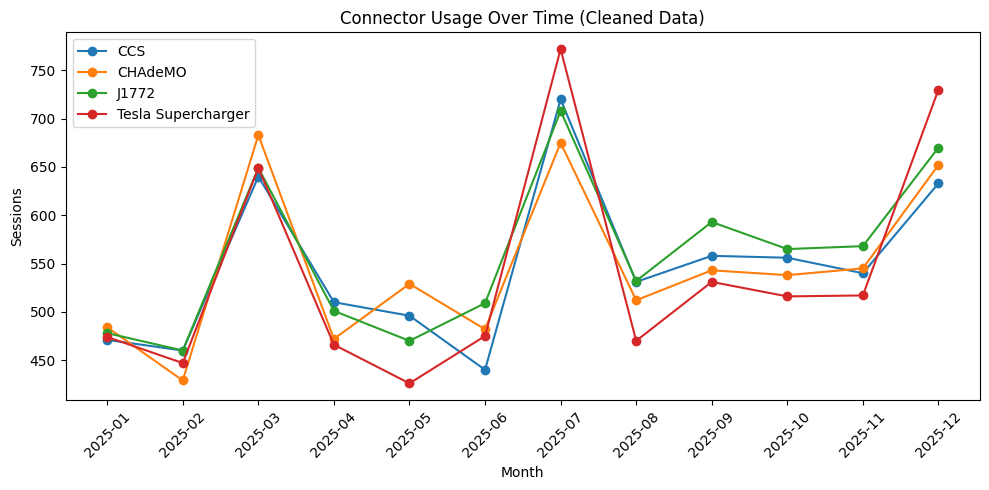

In [ ]:
import matplotlib.pyplot as plt

stations = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_stations.csv")
sessions = pd.read_csv("gs://ds2002-capstone-sp26-v2/team-13/cleaned_sessions.csv")
df = sessions.merge(stations, on="station_id", how="left")

df = df[df["connector_used"].notna()]
df = df[df["connector_used"].str.lower() != "unknown"]
df["session_start"] = pd.to_datetime(df["session_start"])
df["month"] = df["session_start"].dt.to_period("M").astype(str)

connector_trend = df.groupby(["month", "connector_used"]).agg(
    sessions=("session_id", "count")
).reset_index()

plt.figure(figsize=(10, 5))

for c in connector_trend["connector_used"].dropna().unique():
    subset = connector_trend[connector_trend["connector_used"] == c]
    plt.plot(subset["month"], subset["sessions"], marker="o", label=c)

plt.legend()
plt.title("Connector Usage Over Time (Cleaned Data)")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.tight_layout()
plt.show()

The connector type analysis examined CCS, CHAdeMO, J1772, and Tesla Supercharger usage over time using both the SQLite database tables and the cleaned session CSV. The goal was to determine whether CHAdeMO usage is truly declining or whether the decline is caused by messy data, missing connector records, or fragmented vehicle IDs.
After cross-checking connector type with vehicle records, the cleaned data gives stronger evidence than the raw data. If CHAdeMO usage continues to decline even after vehicle IDs are consolidated and missing connector records are reviewed, then the decline is likely real. If CHAdeMO usage increases after cleaning, then part of the decline may have been a data artifact.
Based on the cleaned trend, the city should be cautious about investing in new CHAdeMO ports. CHAdeMO appears less future-oriented than CCS, especially if CCS demand is stable or increasing. The better recommendation is to maintain existing CHAdeMO access for older vehicles but reallocate most new investment toward CCS infrastructure, which is more likely to support future charging demand.

**Reflection Questions**

Question 1:

One of the many data quality issues we found involved the vehicle ids not being consolidated. The vehicles ids were in many different formats, including VH-0014, V_kia_ev6, VEH#0006, and V_tesla_model_y. Since many of the vehicles weren't being recognized as being the same type of vehicle due to the vehicle ids, we consolidated them all into the VH006, VH014, and VH010 format. As a result of cleaning the vehicle ids into one consistent format, all vehicles in the same vehicle type were recognized under the same vehicle id. Furthermore, this resulted in the number of charging session per vehicle type being affected. Which types of vehicles that need more charging could be truly shown with the cleaned data. This is extremely important because decions about the amount of money being put into types of chargers and their locations are being made with this data. Skipping this step of the data cleaning would lead to a misinterpretation of the data, influencing real-world decisions.

Question 2:

The most challenging aspect of GCS was getting our Python code to transfer properly to the GCS bucket. At first, ensuring updates were saved accurately in the bucket was something that took some getting used to. If we had to set up a cloud pipeline from scratch, we would have placed the code for data cleaning and standardization into a separate module, instead of the notebook. This would have made it easier to edit, test, and analyze the final database. Compared to local files, the cloud storage was definitely easier to share and access across multiple devices. However, it was also more complicated to ensure changes and updates were properly stored.

Question 3:

One cleaning decision we made was the fill in missing fields based off of the rest of the availiable data. For example, there were some missing longitude and latitudes. However, the rest of the location data was in tact. Since the zip codes, cities, and states weren't missing, we could use this data to fill in the missing longitudes and latitudes. An alternative approach we could’ve taken is to simply remove or ignore the records with missing latitude and longitude values instead of trying to infer them. This would ensure that all remaining data is fully accurate and not based on assumptions, but it would come at the cost of losing potentially useful entries. Both approachs involves a tradeoff between data completeness, accuracy, and reliability, so the best choice depends on how the dataset is ultimately going to be used.

Question 4:

The most fragile part of our data pipeline is likely the accessing and cleaning stage. The raw data collected often contained errors (duplicates, negative kwh values, and unstandardized vehicle IDs) that suggest the method of data collection is not always precise. If we were to continue adding new data to the pipeline, we would need to address this report issue by implementing a  validation stage that automatically checks for, corrects, and removes inaccurate data.

Question 5:

Our team split up responsibilities by week. To decide which week each member would be responsible for, we discussed what tasks everyone felt most comfortable completing. Ultimately, this method of task assignment worked effectively, as each person was able to contribute in areas that matched their strengths. Splitting up the work by week was also more time-efficient, because we were able to work remotely without worrying about conflicts from editing the same files on different computers. However, if we had an extra week, we would have divided the cleaning and coding tasks more evenly among team members so that everyone could gain hands-on experience with both aspects of the project. Overall, each teammate contributed valuable skills throughout the process. Blake’s most valuable contribution was her management of the team’s workload and her ability to keep everyone on schedule and meeting deadlines. Sahithi's most valuable contribution was handling the data cleaning and preparation, which laid the foundation for our analysis and ensured our results were accurate and reliable. Zoe's most valuable contribution was supporting the cleaning of the data and working on the visualizations. Finally, Joycelyn's most valuable contribution was analyzing code output and using it to answer analytical questions.
